# SMART 2 - Limpieza de Datos
**Objetivo:** Tener el 100% del dataset limpio, con valores nulos tratados y variables categoricas convertidas a numerico.

**Fecha:** Para finales de la tercera semana de julio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data_processing import (
    load_data,
    handle_missing_values,
    encode_categoricals,
    remove_outliers,
    select_features
)

## 1. Cargar el dataset crudo

In [2]:
df = load_data('../data/raw/train.csv')
print(f'Dimensiones originales: {df.shape}')
df.head()

Dimensiones originales: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Manejo de valores faltantes

Estrategia:
- Columnas con >50% nulos: eliminar
- Numericas: imputar con mediana
- Categoricas: imputar con 'None' o moda

In [3]:
df_clean = handle_missing_values(df)

# Verificar que no queden nulos
nulos_restantes = df_clean.isnull().sum().sum()
print(f'Valores nulos restantes: {nulos_restantes}')
print(f'Dimensiones despues de limpiar nulos: {df_clean.shape}')

Valores nulos restantes: 0
Dimensiones despues de limpiar nulos: (1460, 76)


## 3. Conversion de variables categoricas a numericas

Usamos one-hot encoding para convertir las variables de texto a numeros que el modelo pueda entender.

In [4]:
df_encoded = encode_categoricals(df_clean)

print(f'Dimensiones despues de encoding: {df_encoded.shape}')
print(f'\nTipos de datos:')
print(df_encoded.dtypes.value_counts())

Dimensiones despues de encoding: (1460, 235)

Tipos de datos:
bool       197
int64       35
float64      3
Name: count, dtype: int64


## 4. Deteccion y manejo de valores atipicos

Usamos el metodo IQR (Rango Intercurtilico) para detectar outliers en SalePrice.

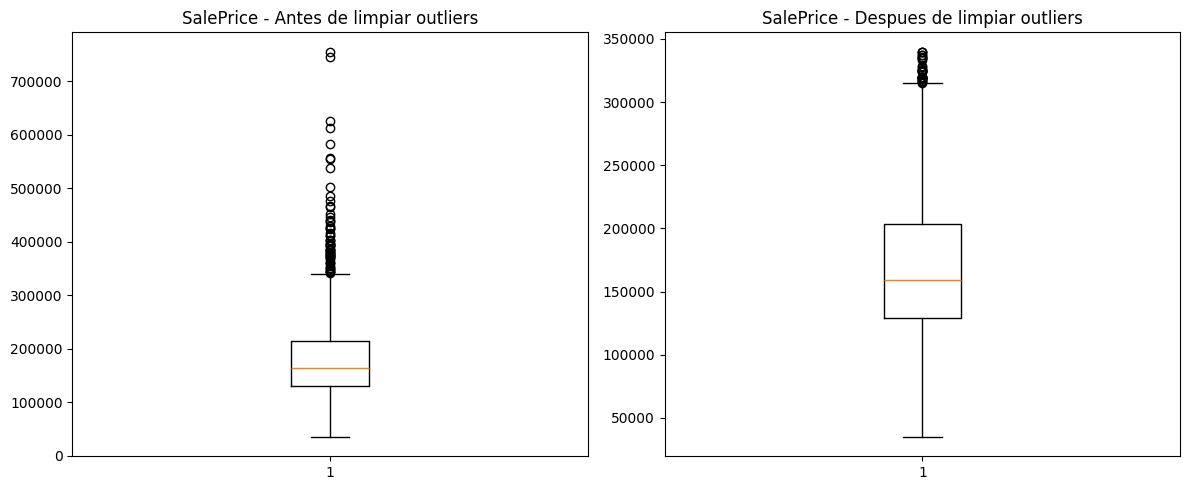

Registros antes: 1460
Registros despues: 1399
Registros eliminados: 61


In [5]:
# Visualizar outliers antes de limpiar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_encoded['SalePrice'])
axes[0].set_title('SalePrice - Antes de limpiar outliers')

df_no_outliers = remove_outliers(df_encoded, column='SalePrice')

axes[1].boxplot(df_no_outliers['SalePrice'])
axes[1].set_title('SalePrice - Despues de limpiar outliers')

plt.tight_layout()
plt.show()

print(f'Registros antes: {len(df_encoded)}')
print(f'Registros despues: {len(df_no_outliers)}')
print(f'Registros eliminados: {len(df_encoded) - len(df_no_outliers)}')

## 5. Seleccion de caracteristicas

Identificamos que variables tienen mayor correlacion con el precio y descartamos las que no aportan informacion.

In [6]:
df_final = select_features(df_no_outliers, target='SalePrice', threshold=0.05)

print(f'Caracteristicas finales: {df_final.shape[1] - 1}')
print(f'Registros finales: {df_final.shape[0]}')
print(f'\nColumnas seleccionadas:')
print(df_final.columns.tolist())

Caracteristicas finales: 160
Registros finales: 1399

Columnas seleccionadas:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'MoSold', 'SalePrice', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotShape_IR2', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LotConfig_CulDSac', 'LotConfig_Inside', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_NAmes', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown

## 6. Verificacion final del dataset

In [7]:
# Verificar que todo este limpio
print('=== VERIFICACION FINAL ===')
print(f'Dimensiones: {df_final.shape}')
print(f'Valores nulos: {df_final.isnull().sum().sum()}')
print(f'Tipos de datos:')
print(df_final.dtypes.value_counts())
print(f'\nPrimeras filas:')
df_final.head()

=== VERIFICACION FINAL ===
Dimensiones: (1399, 161)
Valores nulos: 0
Tipos de datos:
bool       131
int64       27
float64      3
Name: count, dtype: int64

Primeras filas:


,MSSubClass,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,...,GarageCond_Fa,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,SaleType_Con,SaleType_New,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Partial
0,60,65.0,8450,7,2003,2003,196.0,706,150,856,...,False,False,True,False,True,False,False,True,False,False
1,20,80.0,9600,6,1976,1976,0.0,978,284,1262,...,False,False,True,False,True,False,False,True,False,False
2,60,68.0,11250,7,2001,2002,162.0,486,434,920,...,False,False,True,False,True,False,False,True,False,False
3,70,60.0,9550,7,1915,1970,0.0,216,540,756,...,False,False,True,False,True,False,False,True,False,False
4,60,84.0,14260,8,2000,2000,350.0,655,490,1145,...,False,False,True,False,True,False,False,True,False,False


## 7. Guardar dataset limpio

In [8]:
df_final.to_csv('../data/processed/train_clean.csv', index=False)
print('Dataset guardado en data/processed/train_clean.csv')

Dataset guardado en data/processed/train_clean.csv
